**-----------------------------------------------Applying Preprocessing on an Image--------------------------------------------------------**

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


1.Load and visualize a grayscale image using PIL and matplotlib.

○ What is the shape and data type of the loaded image?

○ How are pixel values represented?

In [ ]:
image = Image.open('/content/cat_image.jpeg')

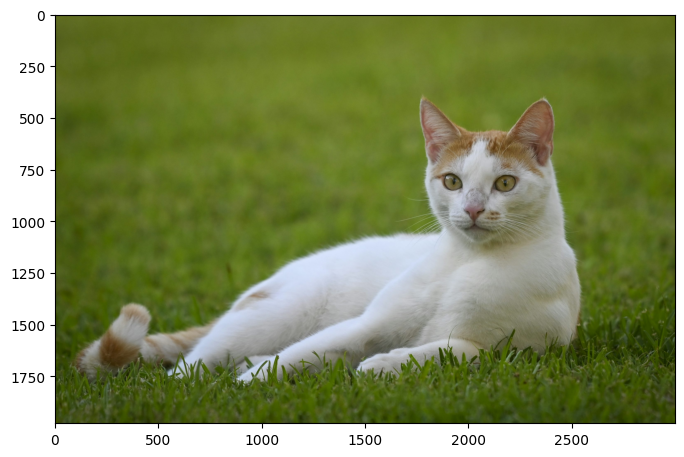

In [ ]:
fig,ax = plt.subplots(figsize=(8,8))
ax.imshow(image)
plt.show()

In [ ]:
image_gray = Image.open('/content/cat_image.jpeg').convert('L')

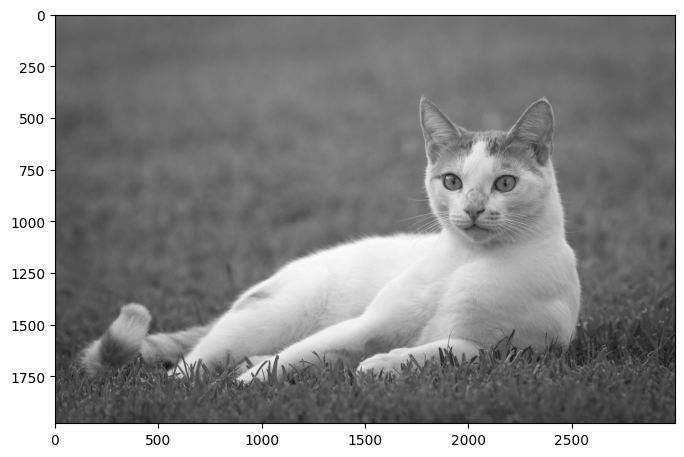

In [ ]:
fig,ax = plt.subplots(figsize=(8,8))
ax.imshow(image_gray, cmap='gray')
plt.show()

In [ ]:
img_array = np.array(image_gray)

print("Shape:", img_array.shape)
print("Data type:", img_array.dtype)
print("Pixel value example:", img_array[100, 100])

Shape: (1977, 3000)
Data type: uint8
Pixel value example: 89


2.Load and visualize a colored (RGB) image.

○ Separate the R, G, B channels.

○ Visualize each channel separately. What differences do you observe?

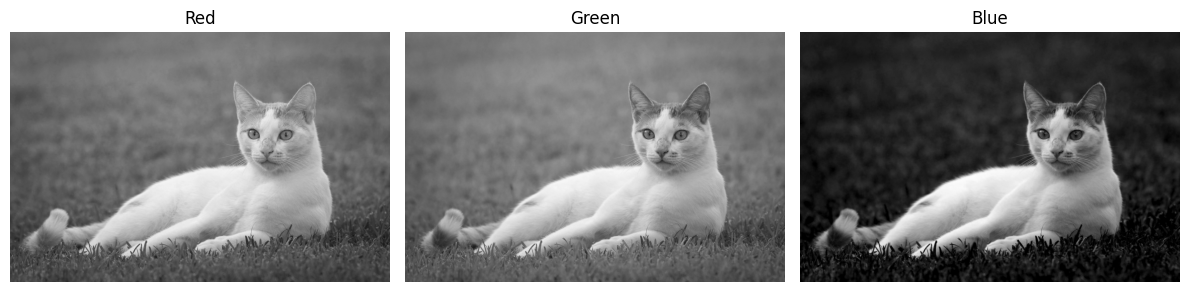

In [ ]:
r,g,b = image.split()


plt.figure(figsize=(12, 4))
for i, channel in enumerate([r, g, b], start=1):
    plt.subplot(1, 3, i)
    plt.imshow(channel, cmap='gray')
    plt.title(['Red', 'Green', 'Blue'][i - 1])
    plt.axis('off')
plt.tight_layout()
plt.show()

3.Convert RGB image to grayscale manually using weighted average (0.2989 * R + 0.5870 * G + 0.1140 * B).

○ Compare this with built-in grayscale conversion

<class 'numpy.ndarray'>


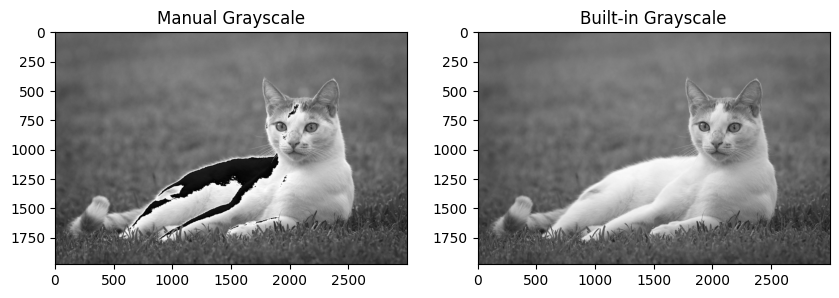

In [ ]:
r_np = np.array(r)
g_np = np.array(g)
b_np = np.array(b)

gray_manual = 0.2989 * r_np + 0.5870 * g_np + 0.34540 * b_np
print(type(gray_manual))
gray_manual = gray_manual.astype(np.uint8)

# Built-in grayscale
gray_builtin = np.array(image.convert('L'))

# Show both
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray_manual, cmap='gray')
plt.title("Manual Grayscale")

plt.subplot(1, 2, 2)
plt.imshow(gray_builtin, cmap='gray')
plt.title("Built-in Grayscale")
plt.show()


4.Implement a 3x3 edge detection kernel (e.g., Sobel or Laplacian) from scratch using NumPy.

○ Apply it to a small grayscale image.

○ Visualize input vs. convolved output.

○ What does the kernel do?

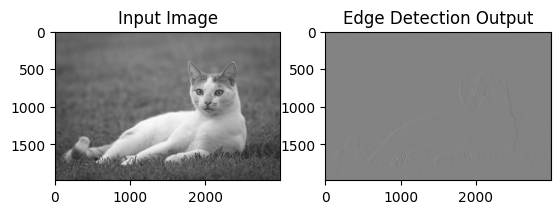

In [ ]:
# Sobel horizontal edge detector (sobel X-operator)
sobel_x = np.array([[ -1,  0,  1],
                    [ -2,  0,  2],
                    [ -1,  0,  1]])

def convolve2d(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    pad = 1
    output = np.zeros((h, w))

    # Padding image
    padded = np.pad(img, pad_width=pad, mode='constant', constant_values=0)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)
    return output

output_img = convolve2d(img_array, sobel_x)

# Visualize
plt.subplot(1, 2, 1)
plt.imshow(img_array, cmap='gray')
plt.title("Input Image")
plt.subplot(1, 2, 2)
plt.imshow(output_img, cmap='gray')
plt.title("Edge Detection Output")
plt.show()


5.Implement zero padding manually and explain its effect.

○ Try padding = 0 and padding = 1. What changes?

In [ ]:
def padding(img, pad):
    return np.pad(img, pad_width=pad, mode='constant', constant_values=0)

# Test
pad0 = padding(img_array, 0)
pad1 = padding(img_array, 1)

print("Original shape:", img_array.shape)
print("Padding=0 shape:", pad0.shape)
print("Padding=1 shape:", pad1.shape)


Original shape: (1977, 3000)
Padding=0 shape: (1977, 3000)
Padding=1 shape: (1979, 3002)


6.Apply stride = 2 and observe how output size changes.

○ Compute output shape mathematically and verify with code

In [ ]:
def convolve_stride(img, kernel, stride=2, padding=0):
    h, w = img.shape
    kh, kw = kernel.shape
    padded = np.pad(img, pad_width=padding, mode='constant')
    oh = (h + 2*padding - kh) // stride + 1
    ow = (w + 2*padding - kw) // stride + 1
    output = np.zeros((oh, ow))

    for i in range(0, oh):
        for j in range(0, ow):
            region = padded[i*stride:i*stride+kh, j*stride:j*stride+kw]
            output[i, j] = np.sum(region * kernel)
    return output

# Apply with stride
out_stride = convolve_stride(img_array, sobel_x, stride=2)
print("Output with stride=2:", out_stride.shape)


Output with stride=2: (988, 1499)


7.Implement and compare following kernels:

○ Identity kernel

○ Sharpening filter

○ Gaussian blur

○ Edge detector (horizontal and vertical)


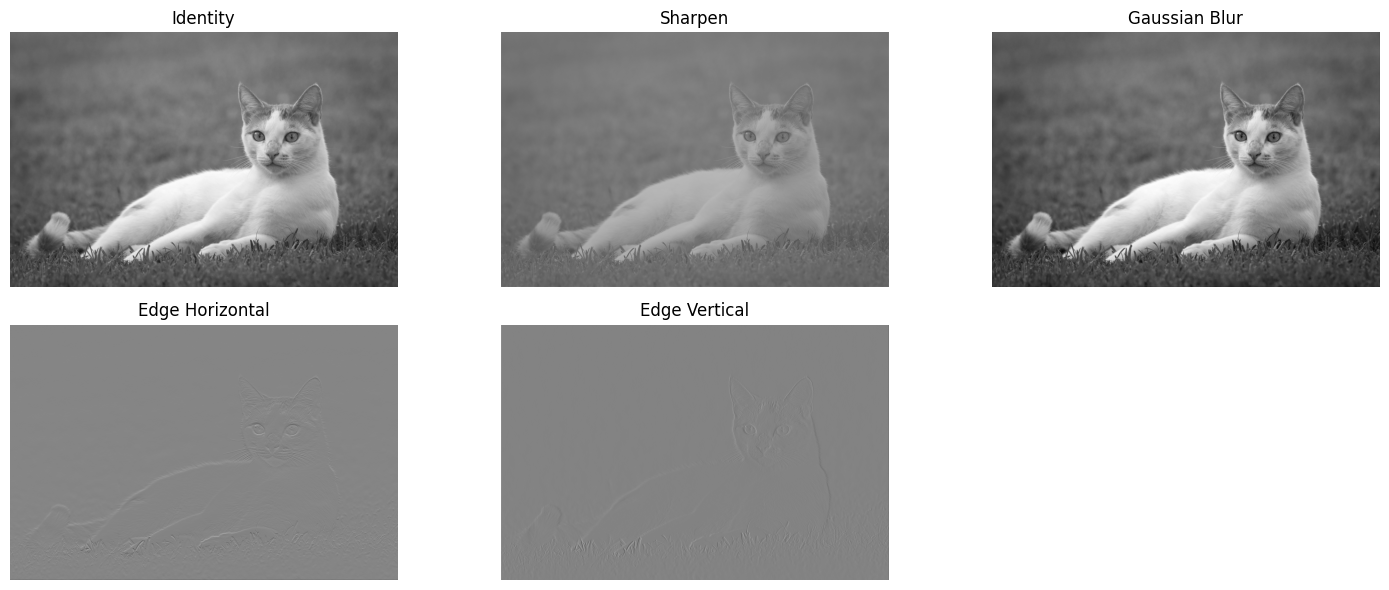

In [ ]:
kernels = {
    "Identity": np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]]),
    "Sharpen": np.array([[0, -1, 0], [-1, 5,-1], [0, -1, 0]]),
    "Gaussian Blur": (1/16)*np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]),
    "Edge Horizontal": np.array([[-1,-2,-1], [0,0,0], [1,2,1]]),
    "Edge Vertical": np.array([[-1,0,1], [-2,0,2], [-1,0,1]])
}

plt.figure(figsize=(15, 6))
for i, (name, k) in enumerate(kernels.items()):
    conv = convolve2d(img_array, k)
    plt.subplot(2, 3, i+1)
    plt.imshow(conv, cmap='gray')
    plt.title(name)
    plt.axis('off')
plt.tight_layout()
plt.show()


8.Write a function to perform convolution for any 2D input and 3x3 kernel.

○ Add options for padding and stride.

○ Test it on various filters and images.

In [ ]:
def generic_conv_2D(img,kernal,padding=0,stride=1):
  h, w = img.shape
  kh, kw = kernal.shape
  padded = np.pad(img, pad_width=padding, mode='constant')
  oh = (h + 2*padding - kh) // stride + 1
  ow = (w + 2*padding - kw) // stride + 1
  output = np.zeros((oh,ow))

  for i in range(0,oh):
    for j in range(0,ow):
      region = padded[i*stride:i*stride+kh, j*stride:j*stride+kw]
      output[i,j] = np.sum(region * kernal)

  return output


9.Analyze how convolving the same image with different kernels gives different information
(edges, textures, etc.).


| Kernel Type     | Use                         |
| --------------- | --------------------------- |
| Identity        | Keeps image unchanged       |
| Sharpening      | Highlights edges            |
| Gaussian Blur   | Smooths/noise reduction     |
| Horizontal Edge | Highlights horizontal lines |
| Vertical Edge   | Highlights vertical lines   |
